# Setup


In [10]:
# Imports
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import pandas as pd

repo_root = Path("/home/volt/bach/SynFlow")
case_study_root = repo_root / "notebooks"
corpus_root = Path("/home/volt/bach/Corpora")

for path in (repo_root, case_study_root):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from SynFlow.Data import (
    merge_txt_files_all_subfolders,
    parsed_file_to_sentences_folder,
)
from SynFlow.Embedding import (
    add_period_pca_coordinates,
    align_w2v_folder,
    build_slot_embedding_points,
    cluster_inspect,
    collect_slot_fillers_by_period,
    detect_reassignments,
    load_gensim_series,
    load_histwords_series,
    plot_cluster_sizes_interactive,
    plot_slot_fillers_by_period,
    run_incremental_clustering,
    run_individual_period_clustering,
    select_slot_fillers,
    summarize_clusters,
    summarize_individual_period_clusters,
    train_w2v_folder,
    vector_norm,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Train W2V

## Prepare training data

In [ ]:
# Convert parsed files to sentences with tokens or lemmas, and optionally drop punctuation.
parsed_input_folder = corpus_root / "deu_news_1995-2025_sentences_parsed"
sentences_output_folder = corpus_root / "deu_news_1995-2025_sentences_token"
sentence_column = "token"  # token or lemma
drop_punct = True
preprocess_workers = 32

parsed_file_to_sentences_folder(
    input_folder=parsed_input_folder,
    output_folder=sentences_output_folder,
    column=sentence_column,
    drop_punct=drop_punct,
    workers=preprocess_workers,
)


In [ ]:
# Merge all tokenised/lemmatised files in all subfolders into a single file for W2V training.
sentences_output_folder = corpus_root / "deu_news_1995-2025_sentences_token"
merged_sentences_output_folder = corpus_root / "deu_news_1995-2025_sentences_token_merged"
merge_workers = 6

merge_txt_files_all_subfolders(
    input_dir=sentences_output_folder,
    output_dir=merged_sentences_output_folder,
    workers=merge_workers,
)


## Train W2V

In [ ]:
training_input_root = corpus_root / "deu_news_1995-2025_sentences_token_merged"
training_output_root = corpus_root / "deu_news_1995-2025_token_w2v"

w2v_vector_size = 300
w2v_window = 4
w2v_min_count = 100
w2v_max_vocab = 50000
w2v_sg = 1
w2v_negative = 5
w2v_ns_exponent = 0.75
w2v_sample = 0
w2v_seed = 42
w2v_epochs = 5
w2v_process_count = 6
w2v_workers_per_model = 1

w2v_training_results = train_w2v_folder(
    input_root=training_input_root,
    output_root=training_output_root,
    vector_size=w2v_vector_size,
    window=w2v_window,
    min_count=w2v_min_count,
    max_vocab=w2v_max_vocab,
    sg=w2v_sg,
    negative=w2v_negative,
    ns_exponent=w2v_ns_exponent,
    sample=w2v_sample,
    seed=w2v_seed,
    epochs=w2v_epochs,
    process_count=w2v_process_count,
    workers_per_model=w2v_workers_per_model,
    show_progress=True,
    overwrite=False,
)

pd.DataFrame(result.to_dict() for result in w2v_training_results)


## Align W2V

In [ ]:
w2v_unaligned_root = corpus_root / "deu_news_1995-2025_token_w2v"
w2v_aligned_root = corpus_root / "deu_news_1995-2025_token_w2v_aligned"

w2v_alignment_results = align_w2v_folder(
    input_root=w2v_unaligned_root,
    output_root=w2v_aligned_root,
    model_filename="{period}.model",
    show_progress=True,
    overwrite=False,
)

pd.DataFrame(result.to_dict() for result in w2v_alignment_results)


# Plot slot filler embedding

Plot fillers for one syntactic slot in their corresponding HistWords time-slice embedding spaces.

In [13]:
slot_df_path = (
    case_study_root
    / "input"
    / "viral_ADJ_1995-2025"
    / "SCD"
    / "viral_ADJ_sfiller_df_token_only_all.csv"
)
period_col = "subfolder"
target_slot = "pa_amod"
min_freq_per_period = 2
top_n_per_period = 50

slot_df = pd.read_csv(slot_df_path)
periods = slot_df[period_col].dropna().astype(str).drop_duplicates().tolist()

slot_filler_freq_df = collect_slot_fillers_by_period(
    slot_df,
    target_slot,
    period_col=period_col,
)
selected_slot_fillers_df = select_slot_fillers(
    slot_filler_freq_df,
    min_freq=min_freq_per_period,
    top_n=top_n_per_period,
    periods=periods,
)

selected_slot_fillers_df.head(20)


,period,slot,filler,count
0,1995-2000,pa_amod_1995-2000,Gene,3
1,1995-2000,pa_amod_1995-2000,Infektionen,3
2,1995-2000,pa_amod_1995-2000,DNA,2
3,1995-2000,pa_amod_1995-2000,Genfähren,2
4,1995-2000,pa_amod_1995-2000,Infekte,2
5,1995-2000,pa_amod_1995-2000,Übeltäter,2
6,2001-2005,pa_amod_2001-2005,Marketing,6
7,2001-2005,pa_amod_2001-2005,Meningitis,4
8,2001-2005,pa_amod_2001-2005,Erbsubstanz,2
9,2006-2010,pa_amod_2006-2010,Marketing,19


In [14]:
separate_embedding_folder = corpus_root / "deu_news_1995-2025_token_w2v_aligned"

embeddings = load_gensim_series(separate_embedding_folder, periods)

slot_embedding_points_df, missing_embedding_fillers_df = build_slot_embedding_points(
    selected_slot_fillers_df,
    embeddings,
)


## Check 0 vectors
* Sometimes empty vectors are filled with 0 and we need to remove them

In [15]:
points_df = slot_embedding_points_df.copy()
points_df["vector_norm"] = points_df["vector"].apply(vector_norm)
zero_df = points_df[
    points_df["vector_norm"] == 0
].copy()

print("zero vectors:", len(zero_df))
print("Total rows:", len(points_df))
print(
    "Zero percentage:",
    len(zero_df) / len(points_df) * 100
)

zero vectors: 0
Total rows: 71
Zero percentage: 0.0


In [16]:
# Drop zero vectors
slot_embedding_points_df["vector_norm"] = slot_embedding_points_df["vector"].apply(vector_norm)
slot_embedding_points_df_clean = slot_embedding_points_df[
    slot_embedding_points_df["vector_norm"] > 0
].copy()

print("Rows before cleaning:", len(slot_embedding_points_df))
print("Rows after cleaning:", len(slot_embedding_points_df_clean))
print("Dropped rows:", len(slot_embedding_points_df) - len(slot_embedding_points_df_clean))

Rows before cleaning: 71
Rows after cleaning: 71
Dropped rows: 0


## PCA

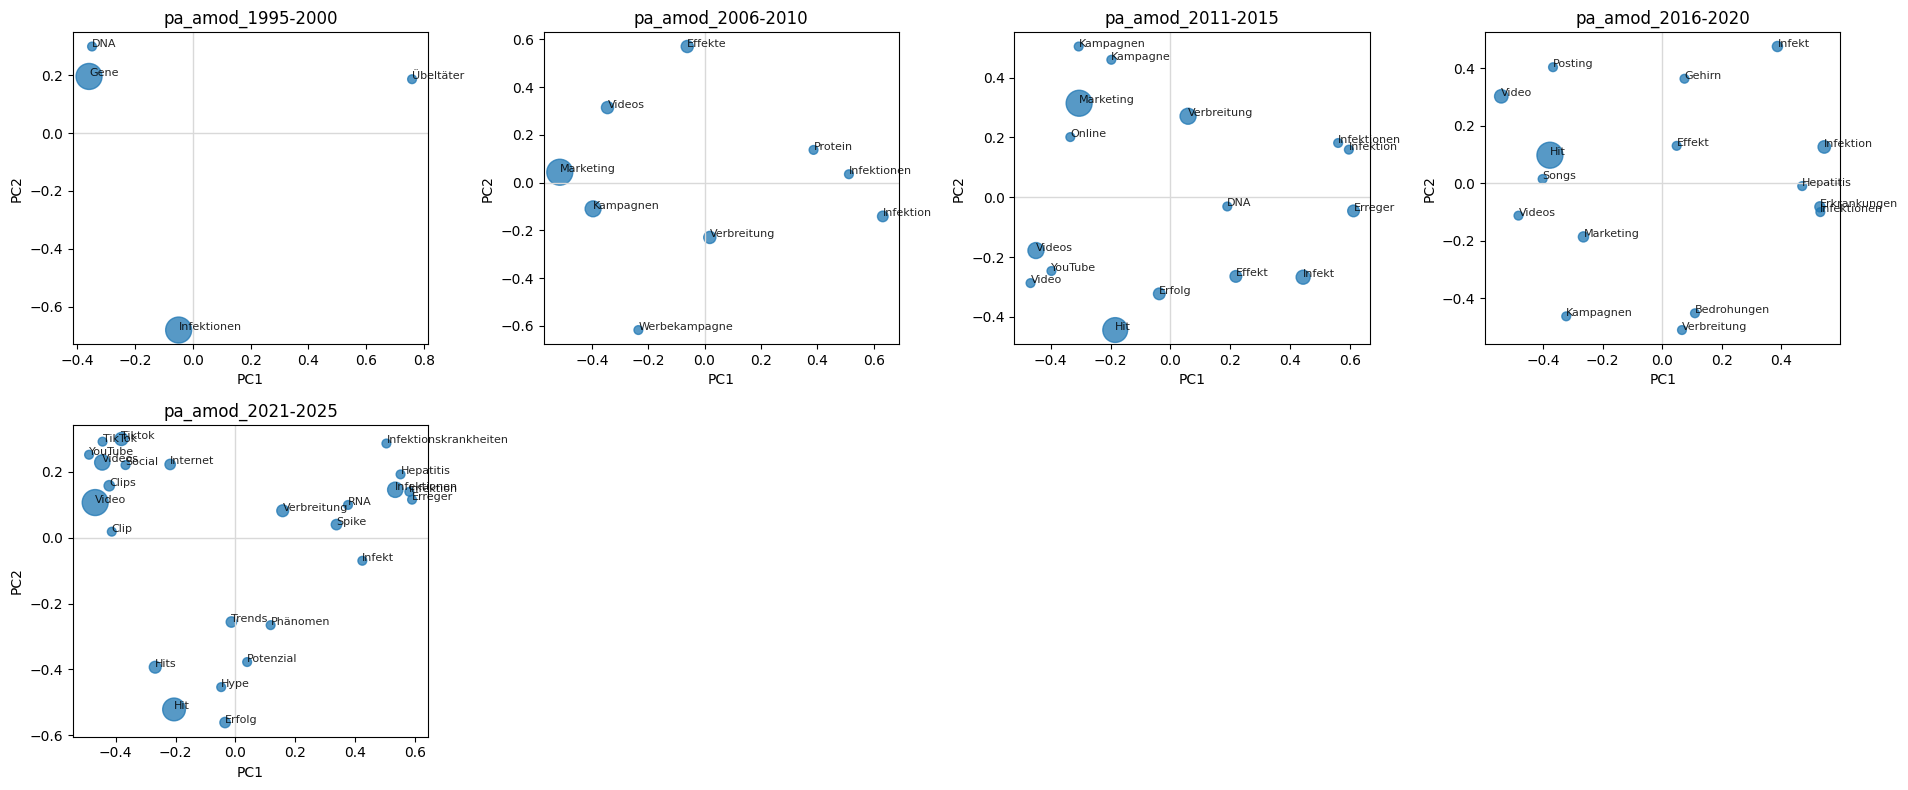

,period,slot,filler,count
0,1995-2000,pa_amod_1995-2000,Genfähren,2
1,1995-2000,pa_amod_1995-2000,Infekte,2
2,2001-2005,pa_amod_2001-2005,Meningitis,4
3,2001-2005,pa_amod_2001-2005,Erbsubstanz,2
4,2006-2010,pa_amod_2006-2010,Marketings,5
5,2006-2010,pa_amod_2006-2010,Ätiologie,2
6,2011-2015,pa_amod_2011-2015,Heiratsanträge,3
7,2011-2015,pa_amod_2011-2015,Infekte,2
8,2011-2015,pa_amod_2011-2015,Meningitis,2
9,2016-2020,pa_amod_2016-2020,Erbguts,2


In [17]:
# PCA
slot_embedding_pca_df = add_period_pca_coordinates(slot_embedding_points_df)

plot_slot_fillers_by_period(slot_embedding_pca_df, target_slot, ncols=4)

missing_embedding_fillers_df

## Cluster in individual periods
* We can do clustering individually for each time period

In [18]:
# -------------------------
# 5. Run individual clustering
# -------------------------

MIN_SIM_INDIVIDUAL_CLUSTER = 0.4

individual_cluster_assignments_df, individual_cluster_centroids_df = run_individual_period_clustering(
    points_df=slot_embedding_points_df_clean,
    min_similarity=MIN_SIM_INDIVIDUAL_CLUSTER,
)

individual_cluster_summary_df = summarize_individual_period_clusters(
    individual_cluster_assignments_df,
)

individual_cluster_summary_df.head(30)


,period,period_cluster_id,cluster_id,n_fillers,total_count,fillers
0,1995-2000,0,1995-2000_0,3,8,"Gene, Infektionen, DNA"
1,1995-2000,1,1995-2000_1,1,2,Übeltäter
2,2001-2005,0,2001-2005_0,1,6,Marketing
3,2006-2010,0,2006-2010_0,1,19,Marketing
4,2006-2010,1,2006-2010_1,2,9,"Kampagnen, Werbekampagne"
5,2006-2010,2,2006-2010_2,3,7,"Infektion, Infektionen, Protein"
6,2006-2010,3,2006-2010_3,1,4,Effekte
7,2006-2010,4,2006-2010_4,1,4,Verbreitung
8,2006-2010,5,2006-2010_5,1,4,Videos
9,2011-2015,0,2011-2015_0,1,12,Marketing


# Cluster incrementally

## Cluster

In [26]:
# -------------------------
# 1. Parameters
# -------------------------

MIN_SIM_TO_EXISTING = 0.3
MIN_SIM_NEW_CLUSTER = 0.3

# If True, old clusters can remain alive even if they receive no members in a period.
# This is usually what you want for diachronic clustering.
ALLOW_INACTIVE_CLUSTERS = True

clusters, cluster_assignments_df = run_incremental_clustering(
    points_df=slot_embedding_points_df_clean,
    min_similarity_to_existing=MIN_SIM_TO_EXISTING,
    min_similarity_new_cluster=MIN_SIM_NEW_CLUSTER,
)

cluster_assignments_df.head(30)

,period,filler,count,cluster_id,event,similarity_to_cluster
0,1995-2000,Gene,3,0,initial,NaN
1,1995-2000,Infektionen,3,0,initial,NaN
2,1995-2000,DNA,2,0,initial,NaN
3,1995-2000,Übeltäter,2,1,initial,NaN
4,2001-2005,Marketing,6,2,new_cluster,0.133813
5,2006-2010,Marketing,19,2,continued,0.749188
6,2006-2010,Kampagnen,7,2,continued,0.334580
7,2006-2010,Effekte,4,0,continued,0.349804
8,2006-2010,Verbreitung,4,0,continued,0.345775
9,2006-2010,Infektion,3,0,continued,0.636289


In [27]:
cluster_summary_df = summarize_clusters(clusters)
cluster_summary_df

,cluster_id,birth_period,last_active_period,period,n_fillers,total_count,fillers
0,0,1995-2000,2021-2025,1995-2000,3,8,"Gene, Infektionen, DNA"
1,0,1995-2000,2021-2025,2006-2010,5,15,"Effekte, Verbreitung, Infektion, Infektionen, ..."
2,0,1995-2000,2021-2025,2011-2015,6,17,"Verbreitung, Effekt, Erreger, DNA, Infektion, ..."
3,0,1995-2000,2021-2025,2016-2020,8,20,"Infektion, Erkrankungen, Bedrohungen, Effekt, ..."
4,0,1995-2000,2021-2025,2021-2025,9,26,"Infektionen, Verbreitung, Spike, Erreger, Hepa..."
5,1,1995-2000,2021-2025,1995-2000,1,2,Übeltäter
6,1,1995-2000,2021-2025,2011-2015,1,4,Infekt
7,1,1995-2000,2021-2025,2016-2020,1,3,Infekt
8,1,1995-2000,2021-2025,2021-2025,1,2,Infekt
9,2,2001-2005,2016-2020,2006-2010,2,26,"Marketing, Kampagnen"


## Inspect clusters

In [39]:
cluster_inspect(clusters)


Cluster 0
Birth: 1995-2000
Last active: 2021-2025
  1995-2000: Gene(3), Infektionen(3), DNA(2)
  2006-2010: Effekte(4), Verbreitung(4), Infektion(3), Infektionen(2), Protein(2)
  2011-2015: Verbreitung(5), Effekt(3), Erreger(3), DNA(2), Infektion(2), Infektionen(2)
  2016-2020: Infektion(5), Erkrankungen(3), Bedrohungen(2), Effekt(2), Gehirn(2), Hepatitis(2), Infektionen(2), Verbreitung(2)
  2021-2025: Infektionen(7), Verbreitung(4), Spike(3), Erreger(2), Hepatitis(2), Infektion(2), Infektionskrankheiten(2), Phänomen(2), RNA(2)

Cluster 1
Birth: 1995-2000
Last active: 2021-2025
  1995-2000: Übeltäter(2)
  2011-2015: Infekt(4)
  2016-2020: Infekt(3)
  2021-2025: Infekt(2)

Cluster 2
Birth: 2001-2005
Last active: 2016-2020
  2001-2005: Marketing(6)
  2006-2010: Marketing(19), Kampagnen(7)
  2011-2015: Marketing(12), Kampagnen(2), Online(2)
  2016-2020: Marketing(3)

Cluster 3
Birth: 2006-2010
Last active: 2021-2025
  2006-2010: Werbekampagne(2)
  2011-2015: Kampagne(2)
  2016-2020: Kamp

In [41]:
fig = plot_cluster_sizes_interactive(
    cluster_summary_df=cluster_summary_df,
    assignments_df=cluster_assignments_df,
    title=f"Incremental filler clusters for {target_slot}",
    top_n=3,
)

In [42]:
reassignments_df = detect_reassignments(cluster_assignments_df)
reassignments_df


,filler,from_period,to_period,from_cluster,to_cluster
0,Kampagnen,2011-2015,2016-2020,2,3
